# 3 - Test particles

Let us explore some options of the models [Vlasov](https://struphy.pages.mpcdf.de/struphy/sections/subsections/models_toy.html#struphy.models.toy.Vlasov), and [GuidingCenter](https://struphy.pages.mpcdf.de/struphy/sections/subsections/models_toy.html#struphy.models.toy.GuidingCenter). In particular, we will

1. Change the geometry
2. Change the loading of the markers
3. Set a static background magnetic field

## Particles in a cylinder

Similar to Tutorial 2, we shall re-create the launch files in the notebook for the purpose of discussion. The default launch files can be created from the console via

```
struphy params Vlasov
struphy params GuidingCenter 
```

This time, we set the simulation domain $\Omega$ to be a cylinder. We explore two options for drawing markers in position space:

- uniform in logical space $[0, 1]^3 = F^{-1}(\Omega)$
- uniform on the cylinder $\Omega$

We start with importing the API and the model:

In [110]:
from struphy import BaseUnits, EnvironmentOptions, Time
from struphy import equils
from struphy import domains
from struphy import grids
from struphy import DerhamOptions
from struphy import maxwellians
from struphy import BoundaryParameters, LoadingParameters, WeightsParameters
from struphy import Simulation

# import model
from struphy.models import Vlasov

We shall create two simulations of the same model, which we store in different output folders, defined through the environment variables:

In [111]:
# light-weight model instances
model = Vlasov()
model_2 = Vlasov()

# environment options
env = EnvironmentOptions()
env_2 = EnvironmentOptions(sim_folder="sim_2")

The other generic options will be the same for both simulations. Here, we just perform one time step and load a cylindrical geometry and we can leave the equilibrium empty:

In [112]:
# time stepping
time_opts = Time(dt=0.2, Tend=0.2)

# geometry
a1 = 1e-6 # to avoid polar singularity, we cut a small hole around the axis.
a2 = 5.0
Lz = 20.0
domain = domains.HollowCylinder(a1=a1, a2=a2, Lz=Lz)

# fluid equilibrium (can be used as part of initial conditions)
equil = None

# grid
grid = grids.TensorProductGrid()

# derham options
derham_opts = DerhamOptions()

Let us instantiate the first simulation:

In [113]:
sim = Simulation(model,
                 env=env,
                 time_opts=time_opts,
                 domain=domain,
                 equil=equil,
                 grid=grid,
                 derham_opts=derham_opts,)

In Struphy there is a convenient method for generating similar simulations with different parameters. 
We can use it to generate the second simulation with different model and environment: 

In [114]:
sim_2 = sim.spawn_sister(model= model_2, env=env_2)

Let us have a look at the simulation domain:

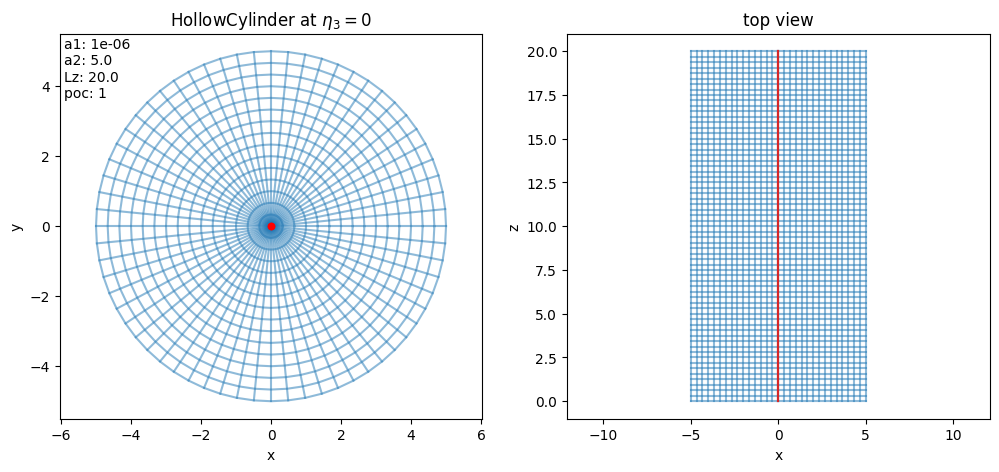

In [115]:
domain.show()

For the second simulation, in the parameters for particle loading we choose `spatial="disc"` in order to draw uniformly on the cross section of the cylinder: 

In [116]:
# species parameters
loading_params = LoadingParameters(Np=1000)
loading_params_2 = LoadingParameters(Np=1000, spatial="disc")

weights_params = WeightsParameters()
boundary_params = BoundaryParameters()

model.kinetic_ions.set_markers(
    loading_params=loading_params, weights_params=weights_params, boundary_params=boundary_params
)
model_2.kinetic_ions.set_markers(
    loading_params=loading_params_2, weights_params=weights_params, boundary_params=boundary_params
)

model.kinetic_ions.set_sorting_boxes()
model_2.kinetic_ions.set_sorting_boxes()

model.kinetic_ions.set_save_data(n_markers=1.0)
model_2.kinetic_ions.set_save_data(n_markers=1.0)

Propagator options and initial conditions shall be the same in both simulations:

In [117]:
# propagator options
model.propagators.push_vxb.options = model.propagators.push_vxb.Options()
model.propagators.push_eta.options = model.propagators.push_eta.Options()

model_2.propagators.push_vxb.options = model_2.propagators.push_vxb.Options()
model_2.propagators.push_eta.options = model_2.propagators.push_eta.Options()

In [118]:
# initial conditions (background + perturbation)
perturbation = None
background = maxwellians.Maxwellian3D(n=(1.0, perturbation))

model.kinetic_ions.var.add_background(background)
model_2.kinetic_ions.var.add_background(background)

Let us now run the first simulation:

In [119]:
sim.run()


Starting simulation run for model Vlasov ...
Struphy run finished.


And now the second simulation:

In [120]:
sim_2.run()


Starting simulation run for model Vlasov ...
Struphy run finished.


We now post-process both simulations, load the generated data and plot the initial particle positions on a cross section of the cylinder:

In [121]:
sim.pproc()

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 302.23it/s]


In [122]:
sim_2.pproc()

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 312.11it/s]


In [123]:
sim.load_plotting_data()

In [124]:
sim_2.load_plotting_data()

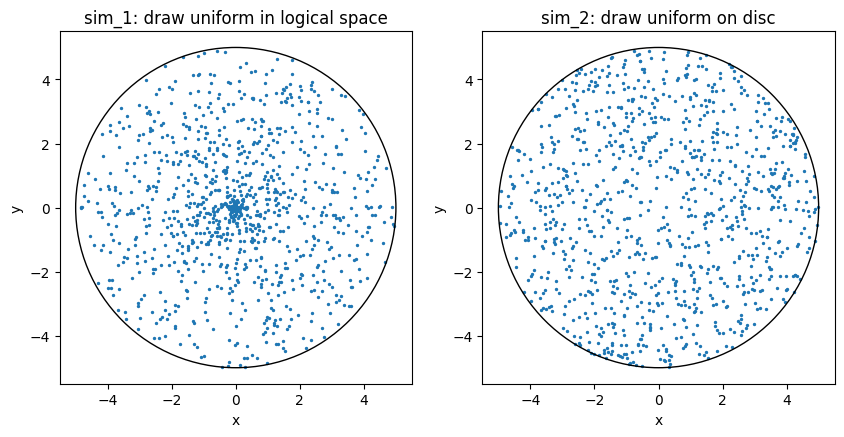

In [ ]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(10, 6))

orbits = sim.orbits.kinetic_ions
orbits_uni = sim_2.orbits.kinetic_ions

plt.subplot(1, 2, 1)
plt.scatter(orbits[0, :, 0], orbits[0, :, 1], s=2.0)
circle1 = plt.Circle((0, 0), a2, color="k", fill=False)
ax = plt.gca()
ax.add_patch(circle1)
ax.set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("sim_1: draw uniform in logical space")

plt.subplot(1, 2, 2)
plt.scatter(orbits_uni[0, :, 0], orbits_uni[0, :, 1], s=2.0)
circle2 = plt.Circle((0, 0), a2, color="k", fill=False)
ax = plt.gca()
ax.add_patch(circle2)
ax.set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("sim_2: draw uniform on disc")

Sometimes you need to load particles more uniformly. It is usefull to reach an homogeneous description of the plasma with a limited number of particles.

It is performed using `loading="sobol_standard"` or `loading="sobol_antithetic"` in the `LoadingParameters` function:


Starting simulation run for model Vlasov ...
Struphy run finished.
100%|██████████| 2/2 [00:00<00:00, 270.28it/s]


Text(0.5, 1.0, 'sim_3: draw using sobol_standard')

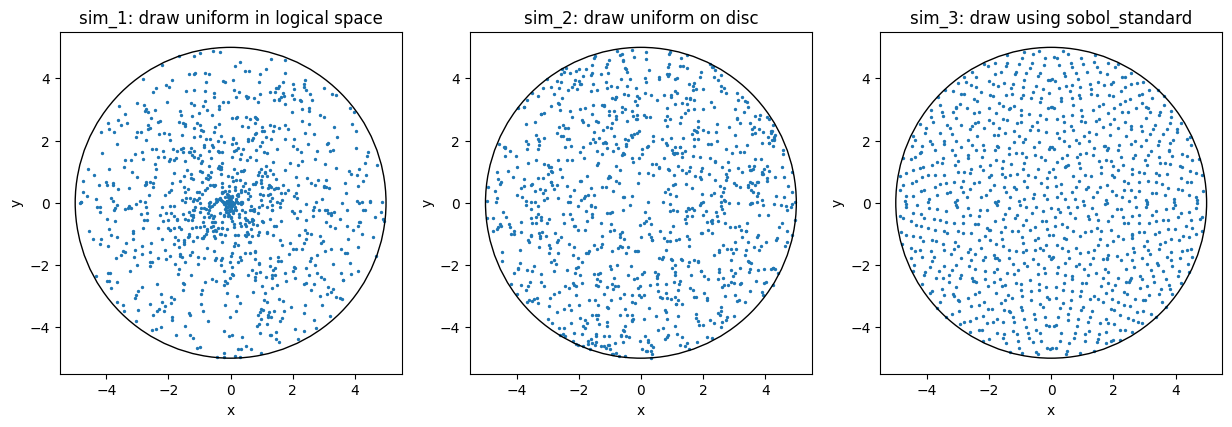

In [ ]:
env_3 = EnvironmentOptions(sim_folder="sim_3")
model_3 = Vlasov()
sim_3 = Simulation.spawn_sister(sim, env=env_3, model=model_3)

# species parameters
loading_params_3 = LoadingParameters(Np=1000, spatial="disc", loading="sobol_standard")

model_3.kinetic_ions.set_markers(
    loading_params=loading_params_3, weights_params=weights_params, boundary_params=boundary_params
)
model_3.kinetic_ions.set_sorting_boxes()

model_3.kinetic_ions.set_save_data(n_markers=1.0)

# propagator options
model_3.propagators.push_vxb.options = model_3.propagators.push_vxb.Options()
model_3.propagators.push_eta.options = model_3.propagators.push_eta.Options()

# initial conditions (background + perturbation)
model_3.kinetic_ions.var.add_background(background)

sim_3.run()
sim_3.pproc()
sim_3.load_plotting_data()

fig = plt.figure(figsize=(15, 6))

orbits_standard = sim_3.orbits.kinetic_ions

plt.subplot(1, 3, 1)
plt.scatter(orbits[0, :, 0], orbits[0, :, 1], s=2.0)
circle1 = plt.Circle((0, 0), a2, color="k", fill=False)
ax = plt.gca()
ax.add_patch(circle1)
ax.set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("sim_1: draw uniform in logical space")

plt.subplot(1, 3, 2)
plt.scatter(orbits_uni[0, :, 0], orbits_uni[0, :, 1], s=2.0)
circle2 = plt.Circle((0, 0), a2, color="k", fill=False)
ax = plt.gca()
ax.add_patch(circle2)
ax.set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("sim_2: draw uniform on disc")

plt.subplot(1, 3, 3)
plt.scatter(orbits_standard[0, :, 0], orbits_standard[0, :, 1], s=2.0)
circle3 = plt.Circle((0, 0), a2, color="k", fill=False)
ax = plt.gca()
ax.add_patch(circle3)
ax.set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("sim_3: draw using sobol_standard")

## Reflecting boundary conditions 

Let us setup a new simulation and run for 50 time steps and with 15 particles in the cylinder.
Moreover, we set reflecting boundary conditions in radial direction, which in Struphy is always the logical direction $\eta_1$.

In [75]:
time_opts = Time(dt=0.2, Tend=10.0)
loading_params = LoadingParameters(Np=15, spatial="disc")
boundary_params = BoundaryParameters(bc=("reflect", "periodic", "periodic"))

In [76]:
# light-weight model instance
model = Vlasov()

sim = Simulation(model,
                 env=env,
                 time_opts=time_opts,
                 domain=domain,
                 equil=equil,
                 grid=grid,
                 derham_opts=derham_opts,)

In [77]:
model.kinetic_ions.set_markers(
    loading_params=loading_params, weights_params=weights_params, boundary_params=boundary_params
)
model.kinetic_ions.set_sorting_boxes()
model.kinetic_ions.set_save_data(n_markers=1.0)

We still have to set the propagator options and the initial conditions:

In [78]:
# propagator options
model.propagators.push_vxb.options = model.propagators.push_vxb.Options()
model.propagators.push_eta.options = model.propagators.push_eta.Options()

# initial conditions (background + perturbation)
perturbation = None
background = maxwellians.Maxwellian3D(n=(1.0, perturbation))

model.kinetic_ions.var.add_background(background)

We can now run the simulation, then post-process the data and plot the resulting orbits:

In [79]:
sim.run()


Starting simulation run for model Vlasov ...
Struphy run finished.


In [80]:
sim.pproc()

100%|██████████| 51/51 [00:00<00:00, 1484.43it/s]


In [81]:
sim.load_plotting_data()

Under `sim.orbits[<species_name>]` one finds a three-dimensional numpy array; the first index refers to the time step, the second index to the particle and the third index to the particle attribute. The first three attributes are the particle positions, followed by the velocities and the (initial and time-dependent) weights.

In [82]:
orbits = sim.orbits.kinetic_ions

Nt = orbits.shape[0]
Np = orbits.shape[1]
Nattr = orbits.shape[2]

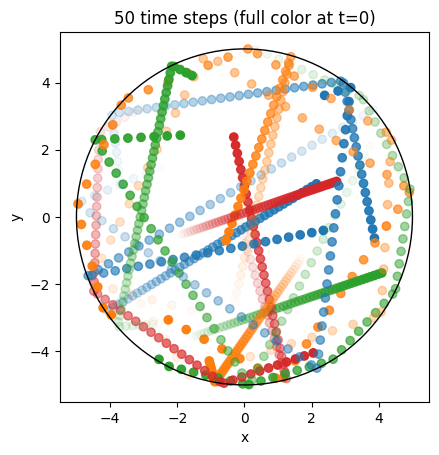

In [83]:
import numpy as np

fig = plt.figure()
ax = fig.gca()

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# create alpha for color scaling
Tend = time_opts.Tend
alpha = np.linspace(1.0, 0.0, Nt + 1)

# loop through particles, plot all time steps
for i in range(Np):
    ax.scatter(orbits[:, i, 0], orbits[:, i, 1], c=colors[i % 4], alpha=alpha)

circle1 = plt.Circle((0, 0), a2, color="k", fill=False)

ax.add_patch(circle1)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"{Nt - 1} time steps (full color at t=0)");

## Particles in a cylinder with a magnetic field

Let us perform as simulation with a magnetic background field. This can be done by setting an object from the `equils` module:

<!-- Let $\Omega \subset \mathbb R^3$ be a cylinder as before. Now, we search for trajectories $(\mathbf x_p, \mathbf v_p): [0,T] \to \Omega \times \mathbb R^3$, $p = 0, \ldots, N-1$ that satisfy

$$
\begin{align}
 \dot{\mathbf x}_p &= \mathbf v_p\,,\qquad && \mathbf x_p(0) = \mathbf x_{p0}\,,
 \\[2mm]
 \dot{\mathbf v}_p &= \mathbf v_p \times \mathbf B_0(\mathbf x_p) \qquad && \mathbf v_p(0) = \mathbf v_{p0}\,,
 \end{align}
$$

where $\mathbf B_0$ is a given magnetic field from an [MHDequilibrium](https://struphy.pages.mpcdf.de/struphy/sections/subsections/mhd_equils.html#mhd-equilibria). 
In addition to the Propagator [PushEta](https://struphy.pages.mpcdf.de/struphy/sections/subsections/propagators_markers.html#struphy.propagators.propagators_markers.PushEta) for the position update, we shall use [PushVxB](https://struphy.pages.mpcdf.de/struphy/sections/subsections/propagators_markers.html#struphy.propagators.propagators_markers.PushVxB) for the velocity update. -->

In [84]:
B0x = 0.0
B0y = 0.0
B0z = 1.0
equil = equils.HomogenSlab(B0x=B0x, B0y=B0y, B0z=B0z)

In order to project the equilibrium on the spline basis for fast evaluation in the particle kernels, we need a Derham complex:

In [85]:
bcs = (("free", "free"), None, None)
derham_opts = DerhamOptions(bcs=bcs)

Now we create the light-weight instance of the model and set the species options. We shall `remove` particles that hit the boundary in $\eta_1$ (radial) direction:

In [86]:
# light-weight model instance
model = Vlasov()

sim_withB = sim.spawn_sister(model=model,
                             equil=equil,
                             derham_opts=derham_opts,)

In [87]:
loading_params = LoadingParameters(Np=20)
boundary_params = BoundaryParameters(bc=("remove", "periodic", "periodic"))
model.kinetic_ions.set_markers(
    loading_params=loading_params, weights_params=weights_params, boundary_params=boundary_params
)
model.kinetic_ions.set_sorting_boxes()
model.kinetic_ions.set_save_data(n_markers=1.0)

# propagator options
model.propagators.push_vxb.options = model.propagators.push_vxb.Options()
model.propagators.push_eta.options = model.propagators.push_eta.Options()

# initial conditions (background + perturbation)
perturbation = None
background = maxwellians.Maxwellian3D(n=(1.0, perturbation))

model.kinetic_ions.var.add_background(background)

Now the usual procedure: run, post-process, load data and finally plot the orbits:

In [88]:
sim_withB.run()


Starting simulation run for model Vlasov ...
Struphy run finished.


In [89]:
sim_withB.pproc()

100%|██████████| 51/51 [00:00<00:00, 1465.44it/s]


In [90]:
sim_withB.load_plotting_data()

In [91]:
orbits = sim_withB.orbits.kinetic_ions

Nt = orbits.shape[0]
Np = orbits.shape[1]

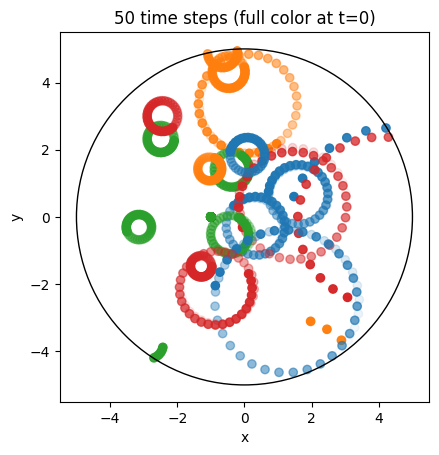

In [92]:
fig = plt.figure()
ax = fig.gca()

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# create alpha for color scaling
Tend = time_opts.Tend
alpha = np.linspace(1.0, 0.0, Nt + 1)

# loop through particles, plot all time steps
for i in range(Np):
    ax.scatter(orbits[:, i, 0], orbits[:, i, 1], c=colors[i % 4], alpha=alpha)

circle1 = plt.Circle((0, 0), a2, color="k", fill=False)

ax.add_patch(circle1)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"{int(Nt - 1)} time steps (full color at t=0)");

## Particles in a Tokamak equilibrium

Let us try a more complicated `MHDequilibrium`, namely from an ASDEX-Upgrade equilibrium stored in an EQDSK file. We instantiate an `EQDSKequilibrium` with default parameters, except for the density:

In [93]:
n1 = 0.0
n2 = 0.0
na = 1.0
equil = equils.EQDSKequilibrium(n1=n1, n2=n2, na=na)

/home/gmile/git_repos/struphy/src/struphy/fields_background/equils.py:1766: UserWarning: self.units =<struphy.physics.physics.Units object at 0x73a83dd17e70>, no rescaling performed in EQDSK output.
  warnings.warn(


Since `EQDSKequilibrium` is an `AxisymmMHDequilibrium`, which is a subclass of `CartesianMHDequilibrium`, we are free to choose any mapping for the simulation (e.g. a Cuboid for Cartesian coordinates). In order to be conforming to the boundary of the equilibrium, we shall choose the `Tokamak` mapping:

In [94]:
num_elements = (28, 72)
degree = (3, 3)
psi_power = 0.6
psi_shifts = (1e-6, 1.0)
domain = domains.Tokamak(equilibrium=equil, num_elements=num_elements, degree=degree, psi_power=psi_power, psi_shifts=psi_shifts)

The `Tokamak` domain is a `PoloidalSplineTorus`, hence

$$
 \begin{aligned}
 x &= R \cos(\phi)\,,
 \\
 y &= -R \sin(\phi)\,,
 \\
 z &= Z\,,
 \end{aligned}
$$

between Cartesian $(x, y, z)$- and Tokamak $(R, Z, \phi)$-coordinates holds, where $(R, Z)$ spans a poloidal plane. Moreover, the Tokamak coordinates are related to general torus coordinates $(r, \theta, \phi)$ via a polar mapping in the poloidal plane:

$$
 \begin{aligned}
 R &= R_0 + r \cos(\theta)\,,
 \\
 Z &= r \sin(\theta)\,,
 \\
 \phi &= \phi\,.
 \end{aligned}
$$

The torus coordinates are related to Struphy logical coordinates $\boldsymbol \eta = (\eta_1, \eta_2, \eta_3) \in [0, 1]^3$ as 

$$
 \begin{aligned}
 r &= a_1 + (a_2 - a_1) \eta_1\,,
 \\
 \theta &= 2\pi \eta_2\,,
 \\
 \phi &= 2\pi \eta_3\,,
 \end{aligned}
$$

where $a_2 > a_1 \geq 0$ are boundaries in the radial $r$-direction.
This can be seen for instance in the `HollowTorus` mapping (more complicated angle parametrizations $\theta(\eta_1, \eta_2)$ are also available, but not discussed here).

Let us plot the equilibrium magnetic field strength:

1. in the poloidal plane at $\phi = 0$
2. in the top view at $z = 0$.

In [95]:
import numpy as np

# logical grid on the unit cube
e1 = np.linspace(0.0, 1.0, 101)
e2 = np.linspace(0.0, 1.0, 101)
e3 = np.linspace(0.0, 1.0, 101)

# move away from the singular point r = 0
e1[0] += 1e-5

In [96]:
# logical coordinates of the poloidal plane at phi = 0
eta_poloidal = (e1, e2, 0.0)
# logical coordinates of the top view at theta = 0
eta_topview_1 = (e1, 0.0, e3)
# logical coordinates of the top view at theta = pi
eta_topview_2 = (e1, 0.5, e3)

In [97]:
# Cartesian coordinates (squeezed)
x_pol, y_pol, z_pol = domain(*eta_poloidal, squeeze_out=True)
x_top1, y_top1, z_top1 = domain(*eta_topview_1, squeeze_out=True)
x_top2, y_top2, z_top2 = domain(*eta_topview_2, squeeze_out=True)

print(f"{x_pol.shape = }")
print(f"{x_top1.shape = }")
print(f"{x_top2.shape = }")

x_pol.shape = (101, 101)
x_top1.shape = (101, 101)
x_top2.shape = (101, 101)


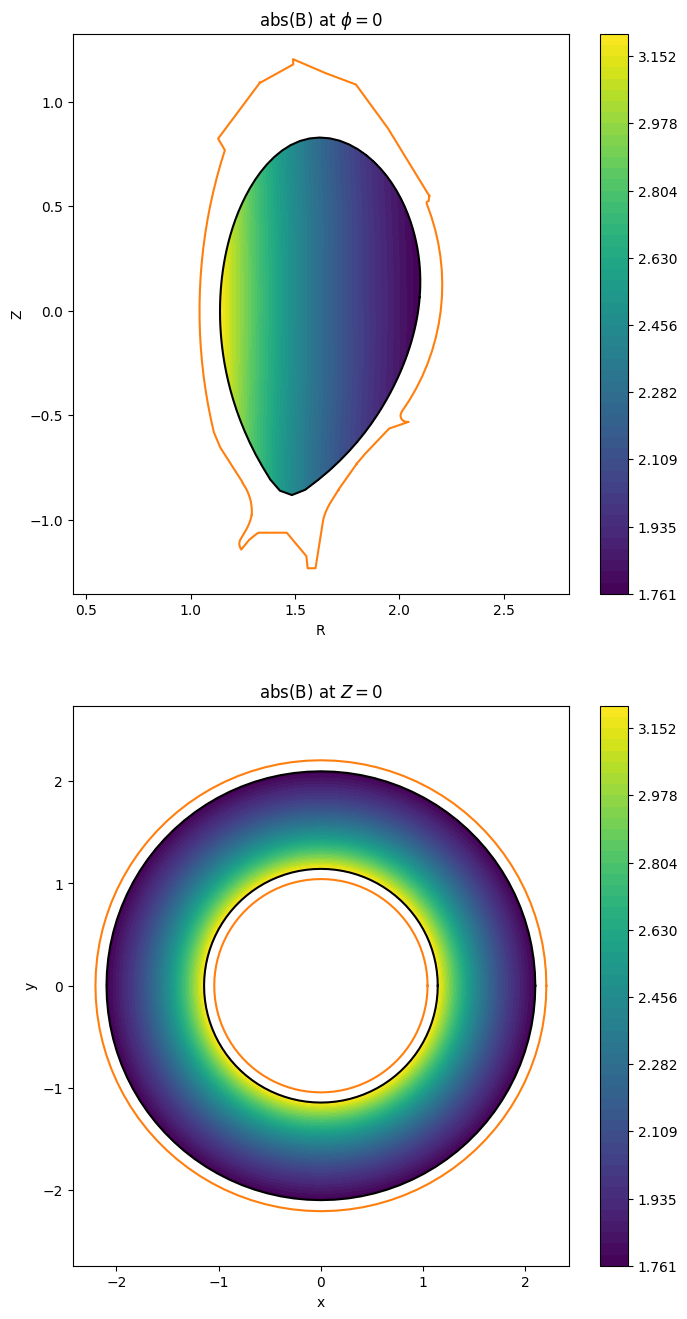

In [98]:
# generate two axes
fig, axs = plt.subplots(2, 1, figsize=(8, 16))
ax = axs[0]
ax_top = axs[1]

# min/max of field strength
equil.domain = domain
Bmax = np.max(equil.absB0(*eta_topview_2, squeeze_out=True))
Bmin = np.min(equil.absB0(*eta_topview_1, squeeze_out=True))
levels = np.linspace(Bmin, Bmax, 51)

# absolute magnetic field at phi = 0
im = ax.contourf(x_pol, z_pol, equil.absB0(*eta_poloidal, squeeze_out=True), levels=levels)

# absolute magnetic field at Z = 0
im_top = ax_top.contourf(x_top1, y_top1, equil.absB0(*eta_topview_1, squeeze_out=True), levels=levels)
ax_top.contourf(x_top2, y_top2, equil.absB0(*eta_topview_2, squeeze_out=True), levels=levels)

# last closed flux surface, poloidal
ax.plot(x_pol[-1], z_pol[-1], color="k")

# last closed flux surface, toroidal
ax_top.plot(x_top1[-1], y_top1[-1], color="k")
ax_top.plot(x_top2[-1], y_top2[-1], color="k")

# limiter, poloidal
ax.plot(equil.limiter_pts_R, equil.limiter_pts_Z, "tab:orange")
ax.axis("equal")
ax.set_xlabel("R")
ax.set_ylabel("Z")
ax.set_title("abs(B) at $\phi=0$")
fig.colorbar(im)
# limiter, toroidal
limiter_Rmax = np.max(equil.limiter_pts_R)
limiter_Rmin = np.min(equil.limiter_pts_R)

thetas = 2 * np.pi * e2
limiter_x_max = limiter_Rmax * np.cos(thetas)
limiter_y_max = -limiter_Rmax * np.sin(thetas)
limiter_x_min = limiter_Rmin * np.cos(thetas)
limiter_y_min = -limiter_Rmin * np.sin(thetas)

ax_top.plot(limiter_x_max, limiter_y_max, "tab:orange")
ax_top.plot(limiter_x_min, limiter_y_min, "tab:orange")
ax_top.axis("equal")
ax_top.set_xlabel("x")
ax_top.set_ylabel("y")
ax_top.set_title("abs(B) at $Z=0$")
fig.colorbar(im_top);

We need a Derham complex for the projection of the equilibrium onto the spline basis:

In [99]:
num_elements = (32, 72, 1)
grid = grids.TensorProductGrid(num_elements=num_elements)

degree = (3, 3, 1)
bcs = (("free", "free"), None, None)
derham_opts = DerhamOptions(degree=degree, bcs=bcs)

We aim to simulate 15000 time steps with a second-order splitting algorithm:

In [100]:
time_opts = Time(dt=0.2, Tend=3000, split_algo="Strang")

We now set up a simulation of 4 specific particle orbits in this equilibrium:

In [101]:
# light-weight model instance
model = Vlasov()

sim_asdex = Simulation(model,
                       env=env,
                       time_opts=time_opts,
                       domain=domain,
                       equil=equil,
                       grid=grid,
                       derham_opts=derham_opts,)

In [102]:
# initial particle positions in phase space
initial = (
    (0.501, 0.001, 0.001, 0.0, 0.0450, -0.04),  # co-passing particle
    (0.511, 0.001, 0.001, 0.0, -0.0450, -0.04),  # counter passing particle
    (0.521, 0.001, 0.001, 0.0, 0.0105, -0.04),  # co-trapped particle
    (0.531, 0.001, 0.001, 0.0, -0.0155, -0.04),
)

loading_params = LoadingParameters(Np=4, seed=1608, specific_markers=initial)
boundary_params = BoundaryParameters(bc=("remove", "periodic", "periodic"))
model.kinetic_ions.set_markers(
    loading_params=loading_params, weights_params=weights_params, boundary_params=boundary_params, bufsize=2.0
)
model.kinetic_ions.set_sorting_boxes()
model.kinetic_ions.set_save_data(n_markers=1.0)

# propagator options
model.propagators.push_vxb.options = model.propagators.push_vxb.Options()
model.propagators.push_eta.options = model.propagators.push_eta.Options()

# initial conditions (background + perturbation)
perturbation = None
background = maxwellians.Maxwellian3D(n=(1.0, perturbation))

model.kinetic_ions.var.add_background(background)

In [103]:
sim_asdex.run()


Starting simulation run for model Vlasov ...
Struphy run finished.


In [46]:
sim_asdex.pproc()

100%|██████████| 15002/15002 [00:09<00:00, 1527.71it/s]


In [47]:
sim_asdex.load_plotting_data()

In [48]:
orbits = sim_asdex.orbits.kinetic_ions

Nt = orbits.shape[0]
Np = orbits.shape[1]

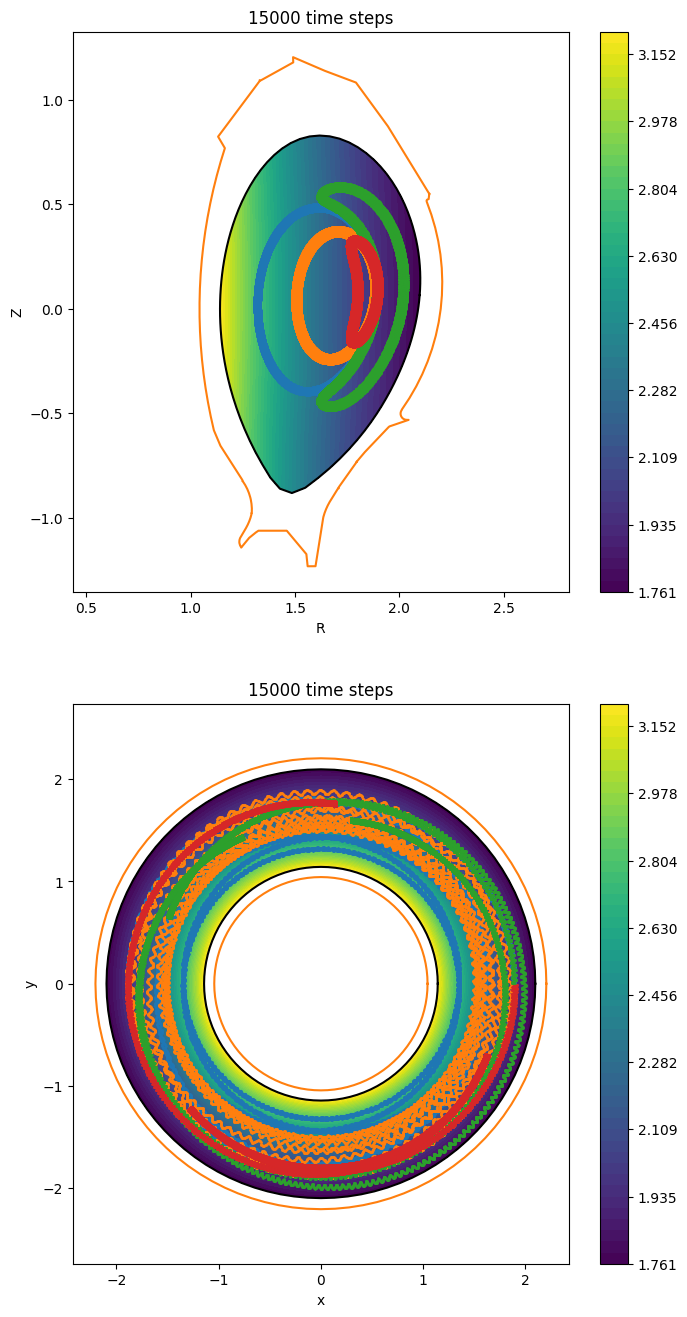

In [49]:
import math

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

dt = time_opts.dt
Tend = time_opts.Tend

for i in range(Np):
    r = np.sqrt(orbits[:, i, 0] ** 2 + orbits[:, i, 1] ** 2)
    # poloidal
    ax.scatter(r, orbits[:, i, 2], c=colors[i % 4], s=1)
    # top view
    ax_top.scatter(orbits[:, i, 0], orbits[:, i, 1], c=colors[i % 4], s=1)

ax.set_title(f"{math.ceil(Tend / dt)} time steps")
ax_top.set_title(f"{math.ceil(Tend / dt)} time steps")
fig

## Guiding-centers in a Tokamak equilibrium

Let us run a similar test for guiding-centers:

In [50]:
from struphy.models import GuidingCenter

# light-weight model instance
model = GuidingCenter()

In [51]:
time_opts = Time(dt=0.1, Tend=100, split_algo="Strang")

sim_gc = sim_asdex.spawn_sister(model=model, time_opts=time_opts)

In [52]:
# initial phase space coordinates
initial = (
    (0.501, 0.001, 0.001, -1.935, 1.72),  # co-passing particle
    (0.501, 0.001, 0.001, 1.935, 1.72),  # couner-passing particle
    (0.501, 0.001, 0.001, -0.6665, 1.72),  # co-trapped particle
    (0.501, 0.001, 0.001, 0.4515, 1.72),
)  # counter-trapped particl

loading_params = LoadingParameters(Np=4, seed=1608, specific_markers=initial)
boundary_params = BoundaryParameters(bc=("remove", "periodic", "periodic"))
model.kinetic_ions.set_markers(
    loading_params=loading_params, weights_params=weights_params, boundary_params=boundary_params, bufsize=2.0
)
model.kinetic_ions.set_sorting_boxes()
model.kinetic_ions.set_save_data(n_markers=1.0)

# propagator options
model.propagators.push_bxe.options = model.propagators.push_bxe.Options(tol=1e-5)
model.propagators.push_parallel.options = model.propagators.push_parallel.Options(tol=1e-5)

# initial conditions (background + perturbation)
perturbation = None
background = maxwellians.GyroMaxwellian2D(n=(1.0, perturbation), equil=equil)

model.kinetic_ions.var.add_background(background)

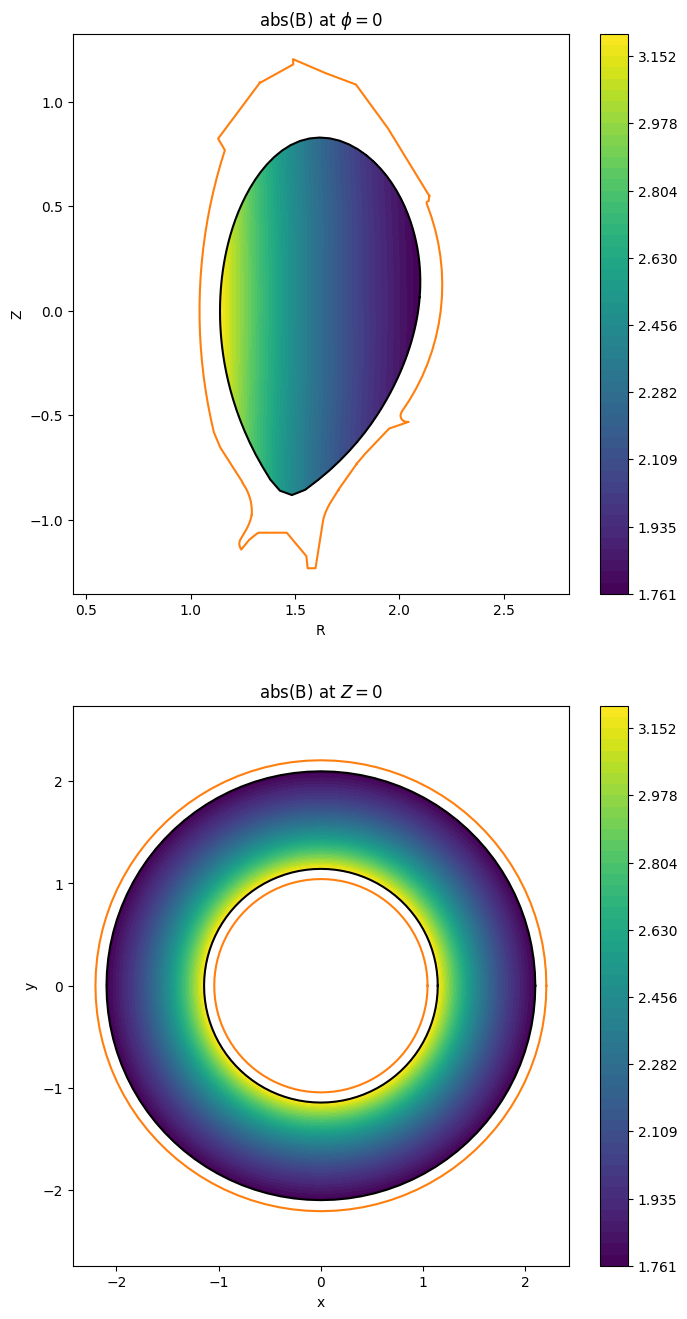

In [53]:
# generate two axes
fig, axs = plt.subplots(2, 1, figsize=(8, 16))
ax = axs[0]
ax_top = axs[1]

# min/max of field strength
equil.domain = domain
Bmax = np.max(equil.absB0(*eta_topview_2, squeeze_out=True))
Bmin = np.min(equil.absB0(*eta_topview_1, squeeze_out=True))
levels = np.linspace(Bmin, Bmax, 51)

# absolute magnetic field at phi = 0
im = ax.contourf(x_pol, z_pol, equil.absB0(*eta_poloidal, squeeze_out=True), levels=levels)

# absolute magnetic field at Z = 0
im_top = ax_top.contourf(x_top1, y_top1, equil.absB0(*eta_topview_1, squeeze_out=True), levels=levels)
ax_top.contourf(x_top2, y_top2, equil.absB0(*eta_topview_2, squeeze_out=True), levels=levels)

# last closed flux surface, poloidal
ax.plot(x_pol[-1], z_pol[-1], color="k")

# last closed flux surface, toroidal
ax_top.plot(x_top1[-1], y_top1[-1], color="k")
ax_top.plot(x_top2[-1], y_top2[-1], color="k")

# limiter, poloidal
ax.plot(equil.limiter_pts_R, equil.limiter_pts_Z, "tab:orange")
ax.axis("equal")
ax.set_xlabel("R")
ax.set_ylabel("Z")
ax.set_title("abs(B) at $\phi=0$")
fig.colorbar(im)
# limiter, toroidal
limiter_Rmax = np.max(equil.limiter_pts_R)
limiter_Rmin = np.min(equil.limiter_pts_R)

thetas = 2 * np.pi * e2
limiter_x_max = limiter_Rmax * np.cos(thetas)
limiter_y_max = -limiter_Rmax * np.sin(thetas)
limiter_x_min = limiter_Rmin * np.cos(thetas)
limiter_y_min = -limiter_Rmin * np.sin(thetas)

ax_top.plot(limiter_x_max, limiter_y_max, "tab:orange")
ax_top.plot(limiter_x_min, limiter_y_min, "tab:orange")
ax_top.axis("equal")
ax_top.set_xlabel("x")
ax_top.set_ylabel("y")
ax_top.set_title("abs(B) at $Z=0$")
fig.colorbar(im_top);

In [54]:
sim_gc.run()


Starting simulation run for model GuidingCenter ...
Struphy run finished.


In [55]:
sim_gc.pproc()

100%|██████████| 1002/1002 [00:00<00:00, 1539.08it/s]


In [56]:
sim_gc.load_plotting_data()

In [57]:
orbits = sim_gc.orbits.kinetic_ions

Nt = orbits.shape[0]
Np = orbits.shape[1]

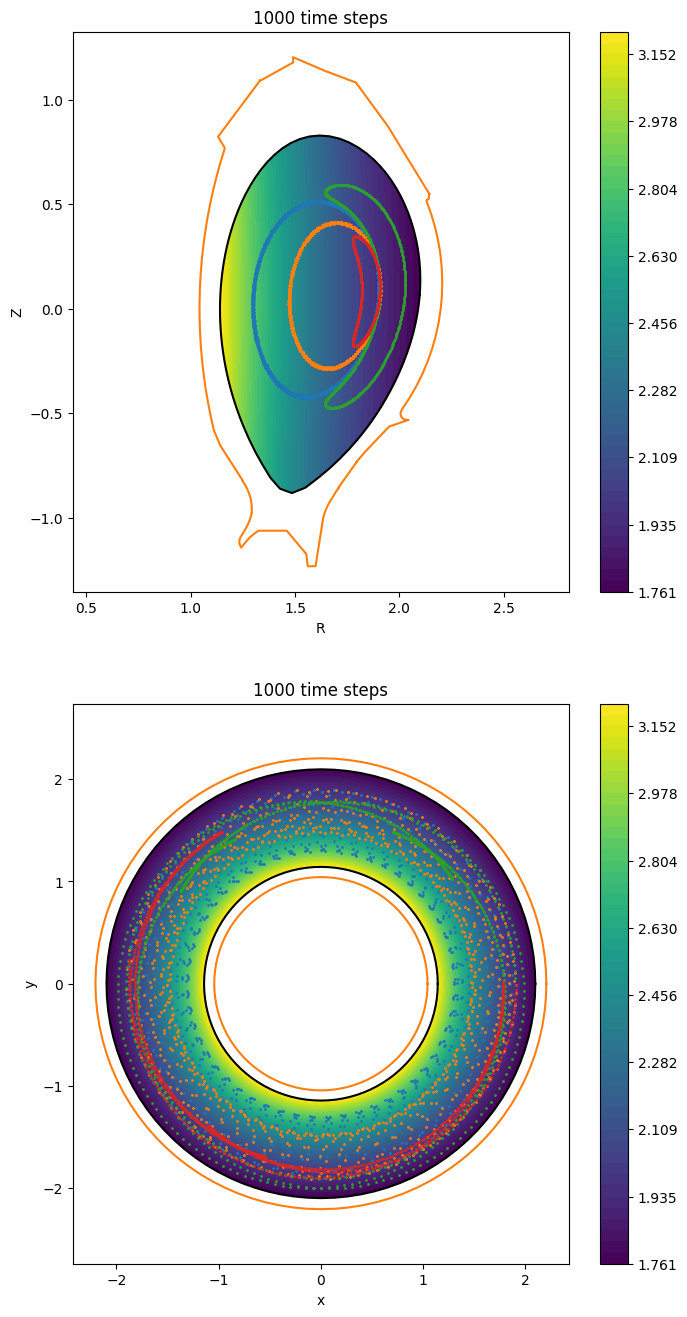

In [58]:
import math

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

dt = time_opts.dt
Tend = time_opts.Tend

for i in range(Np):
    r = np.sqrt(orbits[:, i, 0] ** 2 + orbits[:, i, 1] ** 2)
    # poloidal
    ax.scatter(r, orbits[:, i, 2], c=colors[i % 4], s=1)
    # top view
    ax_top.scatter(orbits[:, i, 0], orbits[:, i, 1], c=colors[i % 4], s=1)

ax.set_title(f"{math.ceil(Tend / dt)} time steps")
ax_top.set_title(f"{math.ceil(Tend / dt)} time steps")
fig